# Titanic Data Analysis

A structured exploratory data analysis of the Titanic dataset using Pandas and Matplotlib.

## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

titanic_raw = pd.read_csv("../Data/titanic_dataset.csv")
titanic = titanic_raw.copy()

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Initial Inspection

In [2]:
print("Shape:", titanic.shape)
titanic.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Data Quality Assessment

In [4]:
missing_percentage = (titanic.isnull().sum() / len(titanic)) * 100

print("Missing values (%):")
print(missing_percentage.round(2))
print("\nDuplicate rows:", titanic.duplicated().sum())
print("\nData types:")
print(titanic.dtypes)

Missing values (%):
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Duplicate rows: 0

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## 4. Data Cleaning

In [5]:
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].median())
titanic.drop(columns=["Cabin"], inplace=True, errors="ignore")
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

print("Shape:", titanic.shape)
print("Duplicates:", titanic.duplicated().sum())
print("\nMissing values:")
print(titanic.isnull().sum())

Shape: (891, 11)
Duplicates: 0

Missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
titanic.to_csv("../Data/titanic_cleaned.csv", index=False)

## 5. Survival Analysis

In [ ]:
survival_counts = (
    titanic["Survived"]
    .map({0: "Did Not Survive", 1: "Survived"})
    .value_counts()
)

overall_survival_rate = titanic["Survived"].mean() * 100
survival_by_sex = titanic.groupby("Sex")["Survived"].mean() * 100
survival_by_class = titanic.groupby("Pclass")["Survived"].mean() * 100

# For age-specific EDA, use observed ages rather than median-imputed ages.
average_age_by_survival = titanic_raw.groupby("Survived")["Age"].mean()

print(survival_counts)
print(f"Overall survival rate: {overall_survival_rate:.2f}%")
print("\nSurvival rate by sex (%):")
print(survival_by_sex.round(2))
print("\nSurvival rate by passenger class (%):")
print(survival_by_class.round(2))
print("\nAverage observed age by survival status:")
print(average_age_by_survival.round(2))

Survived
Did Not Survive    549
Survived           342
Name: count, dtype: int64
Overall survival rate: 38.38%

Survival rate by sex (%):
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival rate by passenger class (%):
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Average observed age by survival status:
Survived
0    30.63
1    28.34
Name: Age, dtype: float64


## 6. Survival by Sex and Passenger Class

In [8]:
survival_by_class_and_sex = (
    titanic.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .mul(100)
    .unstack()
    .round(2)
)

survival_by_class_and_sex

Sex,female,male
Pclass,,
1,96.81,36.89
2,92.11,15.74
3,50.00,13.54


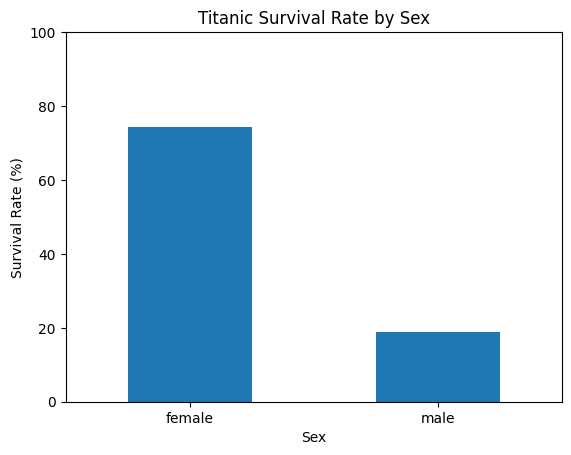

In [9]:
survival_by_sex.plot(
    kind="bar",
    title="Titanic Survival Rate by Sex"
)

plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

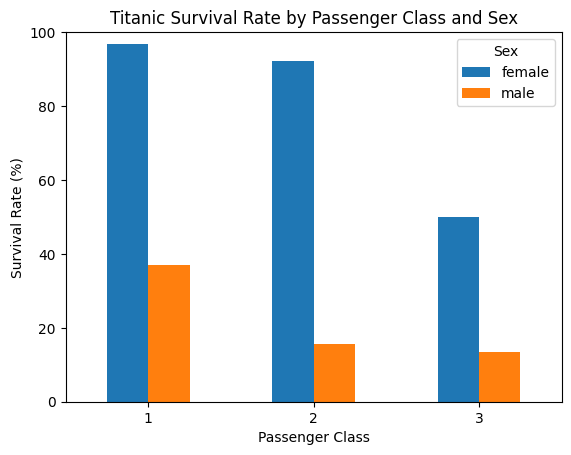

In [10]:
survival_by_class_and_sex.plot(
    kind="bar",
    title="Titanic Survival Rate by Passenger Class and Sex"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.show()

## 7. Age Analysis

For the age-specific exploratory analysis below, only **observed ages** are used. This avoids creating an artificial spike in the age distribution from the median values used earlier to clean missing ages.

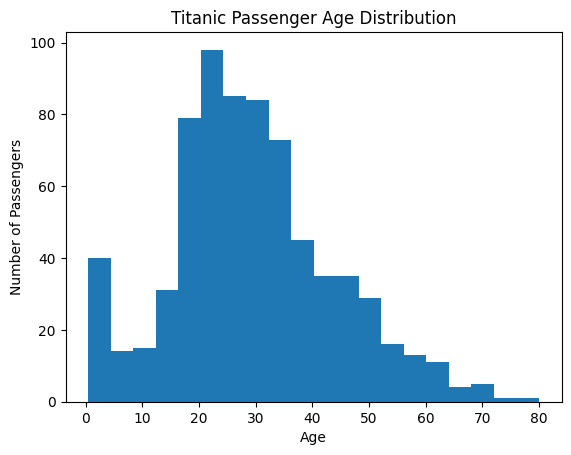

In [11]:
age_data = titanic_raw.dropna(subset=["Age"]).copy()

age_data["Age"].plot(
    kind="hist",
    bins=20,
    title="Titanic Passenger Age Distribution"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### Age Distribution by Survival — Raw Counts

This compares the number of passengers in each age range for survivors and non-survivors. Both groups use the **same bin edges** so the bars are directly comparable.

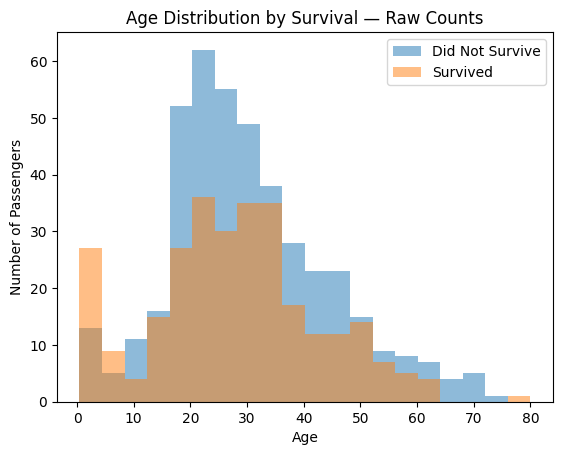

In [12]:
age_bins = np.linspace(age_data["Age"].min(), age_data["Age"].max(), 21)

age_data[age_data["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=age_bins,
    alpha=0.5,
    label="Did Not Survive"
)

age_data[age_data["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=age_bins,
    alpha=0.5,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution by Survival — Raw Counts")
plt.legend()
plt.show()

### Age Distribution by Survival — Normalized

`density=True` normalizes each group so the comparison focuses on **distribution shape**, not the fact that the survivor and non-survivor groups contain different numbers of passengers. The same age-bin edges are used for both groups.

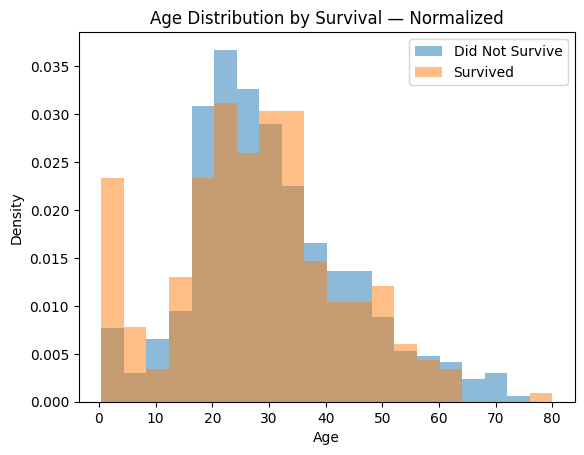

In [13]:
age_data[age_data["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=age_bins,
    alpha=0.5,
    density=True,
    label="Did Not Survive"
)

age_data[age_data["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=age_bins,
    alpha=0.5,
    density=True,
    label="Survived"
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by Survival — Normalized")
plt.legend()
plt.show()

## 8. Family Size Analysis

In [14]:
titanic["Family_size"] = titanic["SibSp"] + titanic["Parch"] + 1

family_survival_rate = (
    titanic.groupby("Family_size")["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

family_survival_rate

Family_size
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64

In [15]:
family_size_counts = titanic.groupby("Family_size").size()

family_size_counts

Family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
dtype: int64

## 9. Embarkation and Passenger Class

This section uses the cleaned dataset. The two missing `Embarked` values were filled with the mode during cleaning.

In [16]:
survival_by_embarked_and_class = (
    titanic.groupby(["Embarked", "Pclass"])["Survived"]
    .mean()
    .mul(100)
    .round(2)
)

survival_by_embarked_and_class

Embarked  Pclass
C         1         69.41
          2         52.94
          3         37.88
Q         1         50.00
          2         66.67
          3         37.50
S         1         58.91
          2         46.34
          3         18.98
Name: Survived, dtype: float64

## 10. Key Findings

- I noticed that you have a significantly higher observed survival rate if you were a female which is 74% compared to being a male at 18% only.
- I also noticed that first-class passengers had higher survival rates than lower-class passengers, and first-class females had the highest observed rate at about 96.8%.
- The age distributions of survival looked much more similar after using density normalization, The raw-count histogram made the difference appear larger because there was more non-survivors overall and the higher disturbation was between the ages 15-35 so age doesnt seem to change the survival outcomes as strongly as sex or passenger class.
- i saw that small families of 2–4 passengers had high survival rates, while passengers travelling alone had lower survival chance.
- sex and passenger class showed the strongest associations with survival, while embarkation ports showed less pronounced differences in this analysis.